In [1]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate classification data
X, y = make_classification(
    n_samples=100,       # number of samples (rows)
    n_features=2,        # 2 input features
    n_informative=2,
    n_redundant=0,
    n_classes=2,         # binary classification (0 and 1)
    random_state=42
)

# Create a DataFrame
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

# Show the first few rows


In [43]:
# calling algo
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Initialize and train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)


KNeighborsClassifier()

array([ 0.07123641,  0.06845616,  0.86199147,  1.2798899 , -0.57500215,
       -0.80804463, -1.36045573,  1.15199146,  0.96423311,  1.02255619,
        0.77861318,  1.28008347,  0.480502  ,  1.80474148,  1.65882246,
       -2.17105282,  1.98522348, -0.07133524,  0.82584805,  0.93343952,
        0.82600732, -2.2813861 , -0.81680628, -1.09831681, -1.20757158,
       -1.21722043, -0.27062383, -1.28568005, -1.87653774, -0.79371387,
       -0.3313761 , -1.75518644, -0.91916686,  0.68057323, -1.64832073,
       -2.3279946 ,  0.85239186, -0.34898484,  1.08659413, -0.56772453,
       -0.78736523,  1.03110238, -1.00634985,  1.53703587, -1.15806823,
        0.4505902 , -1.43483867, -2.02632079,  1.86378908, -1.13207427,
        0.34129395,  2.52983424, -0.94275087,  0.25058844,  1.31217492,
        1.17869556, -0.15013844, -1.5598485 , -2.58590856,  1.03967019,
       -2.00918545,  1.53313849,  1.35536951,  0.15513175,  0.71479373,
       -0.53963044, -1.69302842,  1.65214494,  1.3727107 ,  0.66

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [47]:
# meshgrid
a= np.arange(x_train[:,0].min()-1 , x_train[:,0].max()+1 , step =0.01)
b= np.arange(x_train[:,1].min()-1 , x_train[:,1].max()+1 , step =0.01)
xx , yy = np.meshgrid(a , b)

In [48]:
array = np.array([xx.ravel()  , yy.ravel()]).T

KNeighborsClassifier()

In [49]:
pred = knn.predict(array)

In [50]:
pred= pred.reshape(xx.shape) # makign shape equal to plot

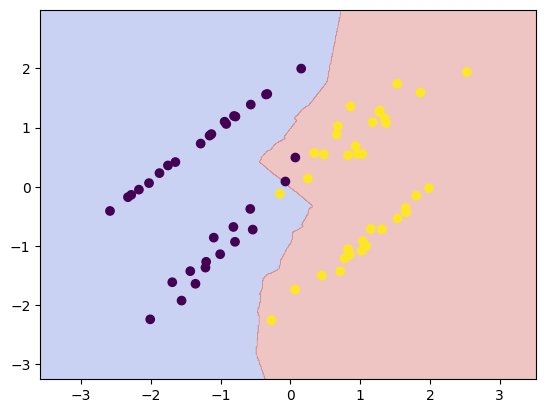

In [54]:
plt.contourf(xx, yy, pred, alpha=0.3, cmap='coolwarm')
plt.scatter(x_train[:,0] , x_train[:,1] , c=y_train)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Generate synthetic 2D binary classification data
X, y = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, random_state=42
)

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 3. Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# 4. Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# 5. Predict on mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plot decision boundary with region colors
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  # colored regions
plt.contour(xx, yy, Z, colors='k', linewidths=0.5)    # boundary lines

# 7. Plot training and test data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap='coolwarm', label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', marker='^', cmap='coolwarm', label="Test")

plt.title("KNN Decision Boundary (k=1)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Generate synthetic 2D binary classification data
X, y = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, random_state=42
)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 3. Train KNN with high k (e.g. 25)
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)

# 4. Create mesh grid over input space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# 5. Predict on grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plot the results
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  # smooth region colors
plt.contour(xx, yy, Z, colors='k', linewidths=0.5)    # boundary line

# Plot training and test data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap='coolwarm', label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', marker='^', cmap='coolwarm', label="Test")

plt.title("KNN Decision Boundary (k=25)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()
